# LSTM Variational Autoencoder (VAE) -- One-Class Classification

## Unterschied zum einfachen Autoencoder

| | LSTM Autoencoder | LSTM VAE |
|---|---|---|
| Bottleneck | fixer Vektor z | Verteilung (μ, σ) |
| Latenzraum | kann "Löcher" haben | glatt, kompakt, N(0,1) |
| Verlust | MSE | MSE + KL-Divergenz |
| Anomalie-Signal | MSE allein | MSE + β·KL |

Die **KL-Divergenz** zwingt alle guten Schlaege in eine kompakte Region um den Ursprung.
Schlechte Schlaege fallen nicht nur durch hohen Rekonstruktionsfehler auf,
sondern landen auch weit ausserhalb dieser Region (hohes KL).

## Reparameterization Trick

Der Encoder gibt μ und log σ² aus. Um z zu samplen und trotzdem Gradienten
durchleiten zu koennen:

```
z = μ + σ · ε,   ε ~ N(0, I)
```

Der Zufallsanteil steckt in ε, nicht in μ/σ -- so koennen Gradienten fliessen.

In [1]:
!pip install tensorflow -q


[notice] A new release of pip is available: 23.1.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.interpolate import interp1d
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 

RANDOM_STATE = 42
tf.random.set_seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

PROJECT_ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / 'requirements.txt').exists() 
)
NORM_DIR = PROJECT_ROOT / '1_DatasetCharacteristics' / 'landmarks' / 'normalized'

print('TensorFlow:', tf.__version__)
print('Project root:', PROJECT_ROOT)

TensorFlow: 2.21.0
Project root: /Users/clarabrilke/ML projects/ML-project


In [3]:
EXCLUDE_COLS = {'phase', 'GOOD', 'BAD'}

def resample_seq(seq, target_len):
    x_old = np.linspace(0, 1, len(seq))
    x_new = np.linspace(0, 1, target_len)
    return interp1d(x_old, seq, axis=0)(x_new)

def load_strokes_for_video(video_stem):
    lm_path     = NORM_DIR / f'{video_stem}-landmarks-norm_10fps.csv'
    stroke_path = NORM_DIR / f'{video_stem}-strokes.csv'
    landmarks   = pd.read_csv(lm_path)
    strokes     = pd.read_csv(stroke_path)
    feature_cols = [c for c in landmarks.columns if c not in EXCLUDE_COLS]
    X = landmarks[feature_cols].values
    fps_ratio = max(1, round(strokes['endzug_end'].max() / len(landmarks)))
    seqs = []
    for _, row in strokes.iterrows():
        start = int(row['endzug_start'] / fps_ratio)
        end   = int(row['endzug_end']   / fps_ratio)
        seq   = X[start:end]
        if len(seq) >= 10:
            seqs.append(seq)
    return seqs, feature_cols, fps_ratio

stroke_files = sorted(NORM_DIR.glob('*-strokes.csv'))
stroke_files = [f for f in stroke_files if not f.stem.startswith('sim')]

print(f'Gefundene Videos: {len(stroke_files)}')
for f in stroke_files:
    label = 'BAD ' if 'BAD' in f.stem.upper() else 'GOOD'
    print(f'  [{label}]  {f.stem}')

all_lengths = []
for sf in stroke_files:
    lm = pd.read_csv(NORM_DIR / f'{sf.stem.replace("-strokes", "")}-landmarks-norm_10fps.csv')
    st = pd.read_csv(sf)
    fps_ratio = max(1, round(st['endzug_end'].max() / len(lm)))
    lengths = ((st['endzug_end'] - st['endzug_start']) / fps_ratio).round().astype(int)
    all_lengths.extend(lengths.tolist())

TARGET_LEN = int(np.median(all_lengths))
print(f'\nSchlaglaengen -- min: {min(all_lengths)}  median: {TARGET_LEN}  max: {max(all_lengths)}')
print(f'TARGET_LEN = {TARGET_LEN} Frames')

good_seqs, bad_seqs = [], []
feature_cols = None
for sf in stroke_files:
    video_stem = sf.stem.replace('-strokes', '')
    seqs, fcols, ratio = load_strokes_for_video(video_stem)
    if feature_cols is None:
        feature_cols = fcols
    resampled = [resample_seq(s, TARGET_LEN) for s in seqs]
    if 'BAD' in video_stem.upper():
        bad_seqs.extend(resampled)
    else:
        good_seqs.extend(resampled)
    label = 'BAD ' if 'BAD' in video_stem.upper() else 'GOOD'
    print(f'  [{label}] {video_stem}: {len(seqs)} Schlaege (fps_ratio={ratio})')

X_good_seq = np.array(good_seqs)
X_bad_seq  = np.array(bad_seqs)
print(f'\nGute Schlaege:      {X_good_seq.shape}')
print(f'Schlechte Schlaege: {X_bad_seq.shape}')

Gefundene Videos: 8
  [BAD ]  cla-BAD-2-strokes
  [BAD ]  cla-BAD-strokes
  [GOOD]  cla-GOOD-fast-strokes
  [GOOD]  cla-GOOD-slow-2-strokes
  [GOOD]  cla-GOOD-slow-strokes
  [GOOD]  man-GOOD-slow-MIRRORED-7.5min-strokes
  [GOOD]  mar-GOOD-fast-strokes
  [GOOD]  mar-GOOD-slow-strokes

Schlaglaengen -- min: 23  median: 28  max: 67
TARGET_LEN = 28 Frames
  [BAD ] cla-BAD-2: 58 Schlaege (fps_ratio=1)
  [BAD ] cla-BAD: 16 Schlaege (fps_ratio=1)
  [GOOD] cla-GOOD-fast: 84 Schlaege (fps_ratio=1)
  [GOOD] cla-GOOD-slow-2: 33 Schlaege (fps_ratio=1)
  [GOOD] cla-GOOD-slow: 67 Schlaege (fps_ratio=1)
  [GOOD] man-GOOD-slow-MIRRORED-7.5min: 147 Schlaege (fps_ratio=1)
  [GOOD] mar-GOOD-fast: 33 Schlaege (fps_ratio=1)
  [GOOD] mar-GOOD-slow: 50 Schlaege (fps_ratio=1)

Gute Schlaege:      (414, 28, 66)
Schlechte Schlaege: (74, 28, 66)


In [4]:
# Train / Validation Split -- nur gute Sequenzen
# Shuffle entlang der Stroke-Achse (axis=0), damit alle Videos gleichmaessig verteilt sind
stroke_indices  = np.random.permutation(len(X_good_seq))
X_good_shuffled = X_good_seq[stroke_indices]

n_train = int(len(X_good_shuffled) * 0.8)
X_train = X_good_shuffled[:n_train]
X_val   = X_good_shuffled[n_train:]

print(f'Training:   {X_train.shape[0]} Sequenzen')
print(f'Validation: {X_val.shape[0]} Sequenzen')
print(f'Schlechte (nur Evaluation): {X_bad_seq.shape[0]} Sequenzen')

Training:   331 Sequenzen
Validation: 83 Sequenzen
Schlechte (nur Evaluation): 74 Sequenzen


## Modell-Architektur

```
Input: (TARGET_LEN x 66)
        |
  LSTM(128)              <-- kodiert Zeitreihe auf letzten Hidden State
        |
  Dense(32) --> z_mean    \
  Dense(32) --> z_log_var  >-- Sampling --> z  (Reparameterization Trick)
                            /
  RepeatVector(TARGET_LEN)
        |
  LSTM(128, return_sequences=True)
        |
  TimeDistributed(Dense(66))
        |
Output: (TARGET_LEN x 66)
```

**Gesamtverlust** = MSE + KL_WEIGHT · KL

`KL_WEIGHT = 1e-3` haelt die KL-Regularisierung schwach genug,
damit der Rekonstruktionsfehler dominiert -- sonst kollabiert der Latenzraum
auf N(0,1) ohne sinnvollen Inhalt (Posterior Collapse).

In [5]:
n_timesteps = TARGET_LEN
n_features  = X_train.shape[2]
LATENT_DIM  = 32
KL_WEIGHT   = 1e-3

class Sampling(layers.Layer):
    """z = mu + exp(0.5 * log_var) * epsilon  (Reparameterization Trick)"""
    def call(self, inputs):
        z_mean, z_log_var = inputs
        epsilon = tf.random.normal(shape=tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

class KLRegularizer(layers.Layer):
    """Fuegt KL-Divergenz als Layer-Loss hinzu (Keras-3-kompatibel)."""
    def __init__(self, weight, **kwargs):
        super().__init__(**kwargs)
        self.weight = weight

    def call(self, inputs):
        z_mean, z_log_var = inputs
        kl = self.weight * tf.reduce_mean(
            tf.reduce_sum(-0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)), axis=1)
        )
        self.add_loss(kl)
        return inputs

def build_lstm_vae(timesteps, features, latent_dim, kl_weight):
    # --- Encoder ---
    inputs    = keras.Input(shape=(timesteps, features), name='input')
    x         = layers.LSTM(128, return_sequences=False, name='encoder_lstm')(inputs)
    z_mean    = layers.Dense(latent_dim, name='z_mean')(x)
    z_log_var = layers.Dense(latent_dim, name='z_log_var')(x)
    z_mean, z_log_var = KLRegularizer(kl_weight, name='kl_reg')([z_mean, z_log_var])
    z = Sampling(name='z')([z_mean, z_log_var])

    # --- Decoder-Layer als Objekte anlegen (Weight-Sharing!) ---
    # Dieselben Layer-Objekte werden im VAE (mit gesampeltem z) UND im
    # deterministischen Decoder (mit z_mean) verwendet. Nach dem Training
    # hat der Decoder automatisch die trainierten Gewichte.
    repeat_layer = layers.RepeatVector(timesteps,                 name='repeat')
    decoder_lstm = layers.LSTM(128, return_sequences=True,        name='decoder_lstm')
    output_layer = layers.TimeDistributed(layers.Dense(features), name='output')

    # VAE: trainiert stochastisch mit gesampeltem z
    x_vae   = repeat_layer(z)
    x_vae   = decoder_lstm(x_vae)
    outputs = output_layer(x_vae)
    vae     = keras.Model(inputs, outputs, name='LSTM_VAE')

    # Encoder-Modell: gibt (z_mean, z_log_var) zurueck
    encoder = keras.Model(inputs, [z_mean, z_log_var], name='Encoder')

    # Deterministischer Decoder fuer Inference: nimmt z_mean direkt (kein Rauschen)
    latent_inputs = keras.Input(shape=(latent_dim,), name='latent_input')
    x_dec   = repeat_layer(latent_inputs)
    x_dec   = decoder_lstm(x_dec)
    dec_out = output_layer(x_dec)
    decoder = keras.Model(latent_inputs, dec_out, name='Decoder')

    return vae, encoder, decoder

model, encoder, decoder = build_lstm_vae(n_timesteps, n_features, LATENT_DIM, KL_WEIGHT)
model.compile(optimizer='adam', loss='mse')
model.summary()

Model: "LSTM_VAE"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 28, 66)    │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ (None, 128)       │     99,840 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 32)        │      4,128 │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 32)        │      4,128 │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ kl_reg              │ [(None, 32),      │          0 │ z_mean[0][0],     │
│ (KLRegularizer)     │ (None, 32)]       │            │ z_log_var[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Sampling)        │ (None, 32)        │          0 │ kl_reg[0][0],     │
│                     │                   │            │ kl_reg[0][1]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ repeat              │ (None, 28, 32)    │          0 │ z[0][0]           │
│ (RepeatVector)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ (None, 28, 128)   │     82,432 │ repeat[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output              │ (None, 28, 66)    │      8,514 │ decoder_lstm[0][… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 199,042 (777.51 KB)

 Trainable params: 199,042 (777.51 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
EPOCHS     = 50
BATCH_SIZE = 32

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 0.4632 - val_loss: 0.1887
Epoch 2/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.1445 - val_loss: 0.1253
Epoch 3/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.1139 - val_loss: 0.1061
Epoch 4/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0995 - val_loss: 0.0995
Epoch 5/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0945 - val_loss: 0.0952
Epoch 6/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0902 - val_loss: 0.0917
Epoch 7/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0870 - val_loss: 0.0880
Epoch 8/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0829 - val_loss: 0.0843
Epoch 9/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0795 - val_loss: 0.0804
Epoch 10/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0760 - val_loss: 0.0786
Epoch 11/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0736 - val_loss: 0.0768
Epoch 12/50
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0

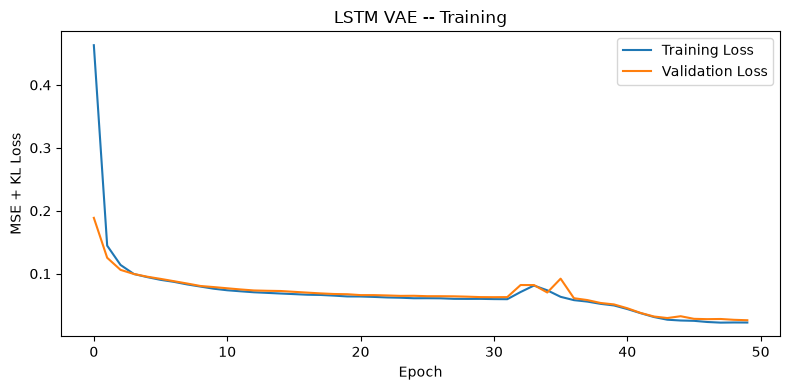

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(history.history['loss'],     label='Training Loss')
ax.plot(history.history['val_loss'], label='Validation Loss')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE + KL Loss')
ax.set_title('LSTM VAE -- Training')
ax.legend()
plt.tight_layout()
plt.show()

## Schwellenwert (Threshold)

Der Anomalie-Score kombiniert Rekonstruktionsfehler und KL-Divergenz:

```
score = MSE + KL_WEIGHT * KL
```

Threshold = 95. Perzentil der Trainings-Scores.
Sequenzen mit score > threshold --> **schlechter Schlag**

In [8]:
def anomaly_scores(encoder, decoder, X):
    # Deterministisch: z_mean direkt durch den Decoder -- kein Sampling-Rauschen
    z_mean_v, z_log_v = encoder.predict(X, verbose=0)
    X_pred = decoder.predict(z_mean_v, verbose=0)
    mse    = np.mean(np.square(X - X_pred), axis=(1, 2))
    kl     = np.sum(-0.5 * (1 + z_log_v - z_mean_v**2 - np.exp(z_log_v)), axis=1)
    return mse, kl, mse + KL_WEIGHT * kl

train_mse, train_kl, train_errors = anomaly_scores(encoder, decoder, X_train)
val_mse,   val_kl,   val_errors   = anomaly_scores(encoder, decoder, X_val)
bad_mse,   bad_kl,   bad_errors   = anomaly_scores(encoder, decoder, X_bad_seq)

THRESHOLD_PERCENTILE = 95
threshold = np.percentile(train_errors, THRESHOLD_PERCENTILE)

print(f'Threshold ({THRESHOLD_PERCENTILE}. Perzentil): {threshold:.6f}')
print()
header = f'{"":22s}  {"Training":>10}  {"Validation":>10}  {"Schlechte":>10}'
print(header)
print('-' * len(header))
print(f'{"MSE (deterministisch)":22s}  {train_mse.mean():>10.6f}  {val_mse.mean():>10.6f}  {bad_mse.mean():>10.6f}')
print(f'{"KL":22s}  {train_kl.mean():>10.4f}  {val_kl.mean():>10.4f}  {bad_kl.mean():>10.4f}')
print(f'{"Score (MSE+KL_W*KL)":22s}  {train_errors.mean():>10.6f}  {val_errors.mean():>10.6f}  {bad_errors.mean():>10.6f}')

Threshold (95. Perzentil): 0.020031

                          Training  Validation   Schlechte
----------------------------------------------------------
MSE (deterministisch)     0.012429    0.016740    0.023455
KL                          5.8532      5.9987      5.2027
Score (MSE+KL_W*KL)       0.018283    0.022739    0.028658


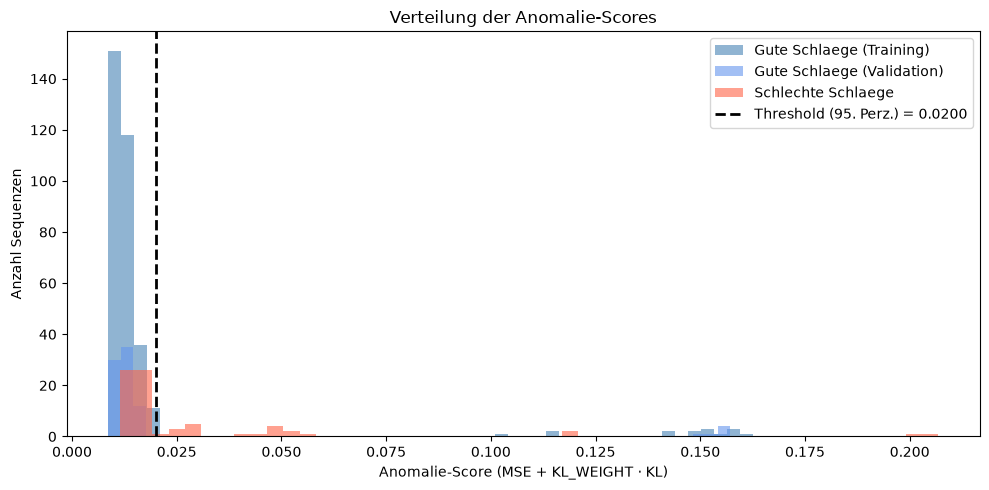

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(train_errors, bins=50, alpha=0.6, label='Gute Schlaege (Training)',   color='steelblue')
ax.hist(val_errors,   bins=50, alpha=0.6, label='Gute Schlaege (Validation)', color='cornflowerblue')
ax.hist(bad_errors,   bins=50, alpha=0.6, label='Schlechte Schlaege',          color='tomato')
ax.axvline(threshold, color='black', linestyle='--', linewidth=2,
           label=f'Threshold ({THRESHOLD_PERCENTILE}. Perz.) = {threshold:.4f}')
ax.set_xlabel('Anomalie-Score (MSE + KL_WEIGHT · KL)')
ax.set_ylabel('Anzahl Sequenzen')
ax.set_title('Verteilung der Anomalie-Scores')
ax.legend()
plt.tight_layout()
plt.show()

## Evaluation

  Evaluation (Validation + Schlechte Schlaege)
              precision    recall  f1-score   support

         Gut       0.59      0.93      0.72        83
    Schlecht       0.78      0.28      0.42        74

    accuracy                           0.62       157
   macro avg       0.69      0.61      0.57       157
weighted avg       0.68      0.62      0.58       157

ROC-AUC: 0.8092


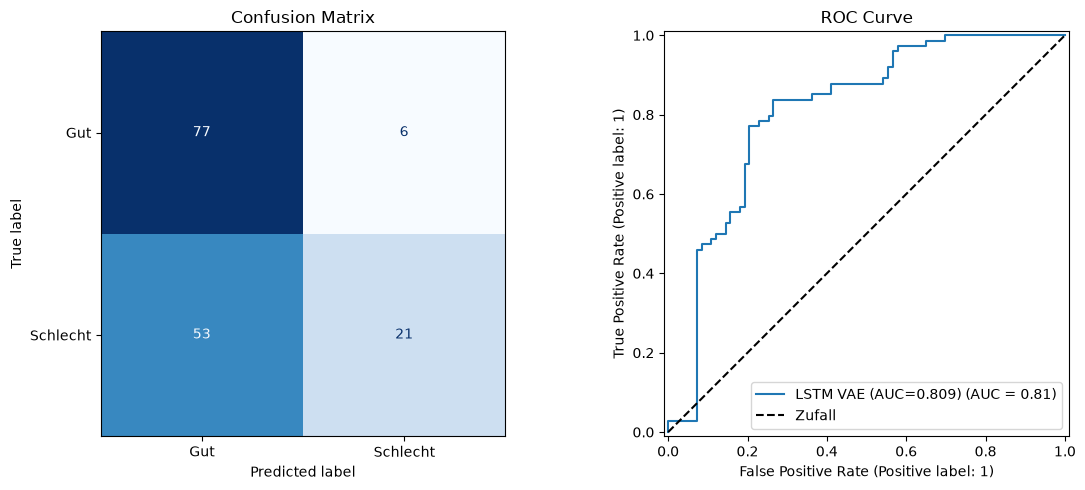

In [10]:
y_scores = np.concatenate([val_errors, bad_errors])
y_true   = np.array([0] * len(val_errors) + [1] * len(bad_errors))
y_pred   = (y_scores > threshold).astype(int)

print('=' * 50)
print('  Evaluation (Validation + Schlechte Schlaege)')
print('=' * 50)
print(classification_report(y_true, y_pred, target_names=['Gut', 'Schlecht']))

auc = roc_auc_score(y_true, y_scores)
print(f'ROC-AUC: {auc:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay(
    confusion_matrix(y_true, y_pred),
    display_labels=['Gut', 'Schlecht']
).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix')

RocCurveDisplay.from_predictions(
    y_true, y_scores,
    name=f'LSTM VAE (AUC={auc:.3f})',
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], 'k--', label='Zufall')
axes[1].set_title('ROC Curve')
axes[1].legend()

plt.tight_layout()
plt.show()

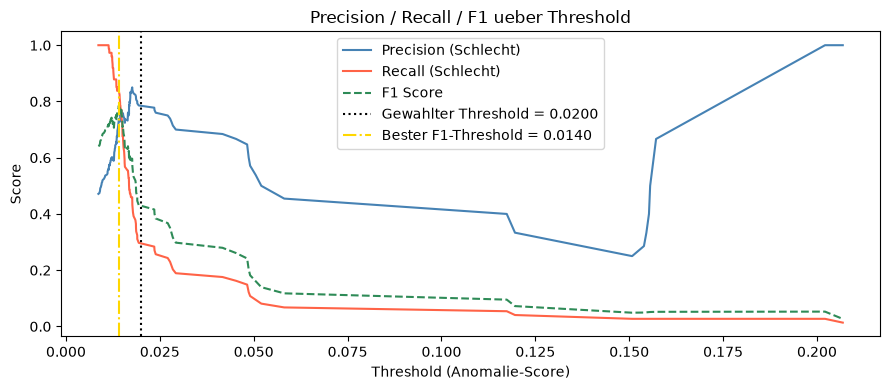

Bester F1-Score: 0.7848 bei Threshold 0.014049


In [11]:
from sklearn.metrics import precision_recall_curve

precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores, pos_label=1)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx  = np.argmax(f1_scores)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(pr_thresholds, precision[:-1], label='Precision (Schlecht)', color='steelblue')
ax.plot(pr_thresholds, recall[:-1],    label='Recall (Schlecht)',    color='tomato')
ax.plot(pr_thresholds, f1_scores[:-1], label='F1 Score',             color='seagreen', linestyle='--')
ax.axvline(threshold, color='black', linestyle=':',
           label=f'Gewahlter Threshold = {threshold:.4f}')
ax.axvline(pr_thresholds[best_idx], color='gold', linestyle='-.',
           label=f'Bester F1-Threshold = {pr_thresholds[best_idx]:.4f}')
ax.set_xlabel('Threshold (Anomalie-Score)')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall / F1 ueber Threshold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Bester F1-Score: {f1_scores[best_idx]:.4f} bei Threshold {pr_thresholds[best_idx]:.6f}')